# PRAKTIKUM PENAMBANGAN DATA (PPD)
## MODUL 4: REGRESSION

* **Nama**: Januarsyah Akbar
* **NIM**: 24/535846/SV/24314
* **Kelas**: B2
* **Mata Kuliah**: Praktikum Penambangan Data (SVPL214610)
* **Program Studi**: D4 Teknologi Rekayasa Perangkat Lunak, Sekolah Vokasi UGM

---

## A. LANGKAH PERCOBAAN (KC House Data)
Dataset: [House Sales in King County, USA](https://www.kaggle.com/datasets/shivachandel/kc-house-data)

### 1. Impor Pustaka

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

### 2. Load Dataset

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/ganjar87/data_science_practice/main/kc_house_data.csv')

### 3. Exploratory Data Analysis (EDA)
**a. Melihat 5 baris pertama dan terakhir pada dataset**

In [3]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
df.tail()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287
21612,1523300157,20141015T000000,325000.0,2,0.75,1020,1076,2.0,0,0,...,7,1020,0,2008,0,98144,47.5941,-122.299,1020,1357


**b. Melihat deskripsi statistik**

In [5]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


**c. Melihat histogram variabel numerik**

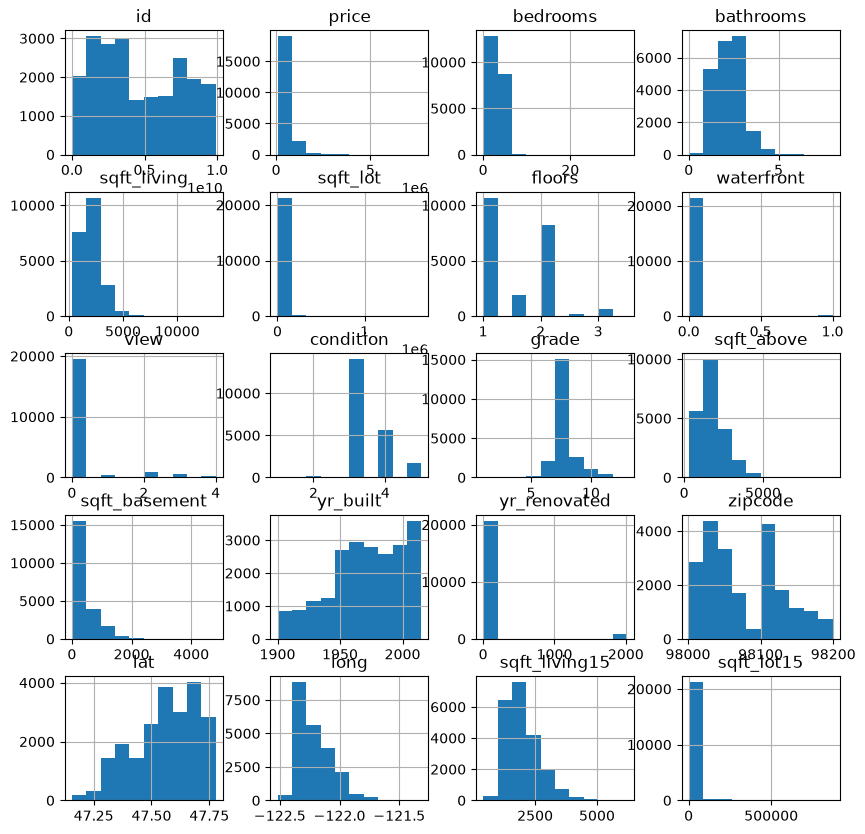

In [6]:
df.hist(figsize=(10,10))
plt.show()

**d. Mengecek korelasi atribut numerik**

In [7]:
df.corr(numeric_only=True)

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,1.000000,-0.016762,0.001286,0.005160,-0.012258,-0.132109,0.018525,-0.002721,0.011592,-0.023783,0.008130,-0.010842,-0.005151,0.021380,-0.016907,-0.008224,-0.001891,0.020799,-0.002901,-0.138798
price,-0.016762,1.000000,0.308350,0.525138,0.702035,0.089661,0.256794,0.266369,0.397293,0.036362,0.667434,0.605567,0.323816,0.054012,0.126434,-0.053203,0.307003,0.021626,0.585379,0.082447
bedrooms,0.001286,0.308350,1.000000,0.515884,0.576671,0.031703,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477600,0.303093,0.154178,0.018841,-0.152668,-0.008931,0.129473,0.391638,0.029244
bathrooms,0.005160,0.525138,0.515884,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685342,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175
sqft_living,-0.012258,0.702035,0.576671,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876597,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286
sqft_lot,-0.132109,0.089661,0.031703,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183512,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557
floors,0.018525,0.256794,0.175429,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
waterfront,-0.002721,0.266369,-0.006582,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
view,0.011592,0.397293,0.079532,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575
condition,-0.023783,0.036362,0.028472,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158214,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406


**e. Mengecek missing value**

In [8]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

**f. Mengecek atribut kategorikal**

In [9]:
df_X = df.drop(['id', 'date', 'price'], axis=1)
y = df['price']
cats = df_X.select_dtypes(include=['object', 'bool']).columns
print(cats)

Index([], dtype='str')


### 4. Modelling & Evaluasi
**a. Linear Regression**

In [10]:
df_X = df.drop(['id', 'date', 'price'], axis=1)
df_y = df['price']

X = df_X.astype(float).values
y = df_y.astype(float).values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
reg = LinearRegression()
reg.fit(X_train, y_train)

print('coef of determination training ', reg.score(X_train, y_train))
print('coef of determination testing ', reg.score(X_test, y_test))

print('coefficient')
print(reg.coef_)
print('intercept')
print(reg.intercept_)

print('prediction')
y_pred = reg.predict(X_test)
print(y_pred[:10])
print('real value')
print(y_test[0:10])

coef of determination training  0.6995155846436754
coef of determination testing  0.6994627057969799
coefficient
[-3.43081477e+04  4.03129700e+04  1.12001375e+02  9.91841247e-02
  5.27154218e+03  5.43877177e+05  5.50830616e+04  2.31460673e+04
  9.49081794e+04  7.22190667e+01  3.97823081e+01 -2.59441847e+03
  2.19209734e+01 -5.56358731e+02  5.95216324e+05 -1.96904658e+05
  1.62077488e+01 -3.30430480e-01]
intercept
6641646.708119436
prediction
[ 458597.06764164  748993.75994819 1243303.75799049 1665116.95095426
  737302.05741735  283239.58524983  831732.87582316  495383.02095342
  385779.81919031  474179.42285142]
real value
[ 365000.  865000. 1038000. 1490000.  711000.  211000.  790000.  680000.
  384500.  605000.]


*Evaluasi Model Linear Regression dengan RMSE dan $R^2$*

In [11]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('rmse : ', rmse)
print('r2 : ', r2)

rmse :  208296.72772119232
r2 :  0.6994627057969799


*Visualisasi Perbandingan Prediksi Linear Regression (50 Sampel)*

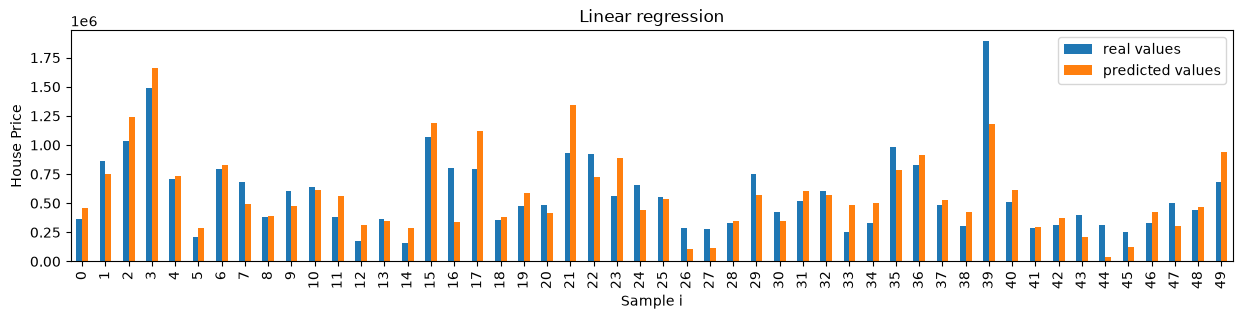

In [12]:
data1 = pd.Series(y_test[:50].ravel())
data2 = pd.Series(y_pred[:50].ravel())

df_new = pd.concat([data1, data2], keys=['real values', 'predicted values'], axis=1)
df_new.plot(kind='bar', figsize=(15,3))

plt.title("Linear regression")
plt.xlabel('Sample i')
plt.ylabel('House Price')
plt.show()

**b. Decision Tree Regression**

In [13]:
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)

print('coef of determination training ', dt.score(X_train, y_train))
print('coef of determination testing ', dt.score(X_test, y_test))

print('prediction')
y_pred_dt = dt.predict(X_test)
print(y_pred_dt[:10])
print('real value')
print(y_test[0:10])

coef of determination training  0.9185274272472612


coef of determination testing  0.7586162393034989
prediction
[ 372512.5         837693.06862745 1087247.96153846 1984617.64705882
  656314.08658009  237079.87179487  849106.21276596  517991.26363636
  366270.875       519039.40166667]
real value
[ 365000.  865000. 1038000. 1490000.  711000.  211000.  790000.  680000.
  384500.  605000.]


*Evaluasi Model Decision Tree dengan RMSE dan $R^2$*

In [14]:
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print('rmse : ', rmse_dt)
print('r2 : ', r2_dt)

rmse :  186675.48396982581
r2 :  0.7586162393034989


*Visualisasi Perbandingan Prediksi Decision Tree (50 Sampel)*

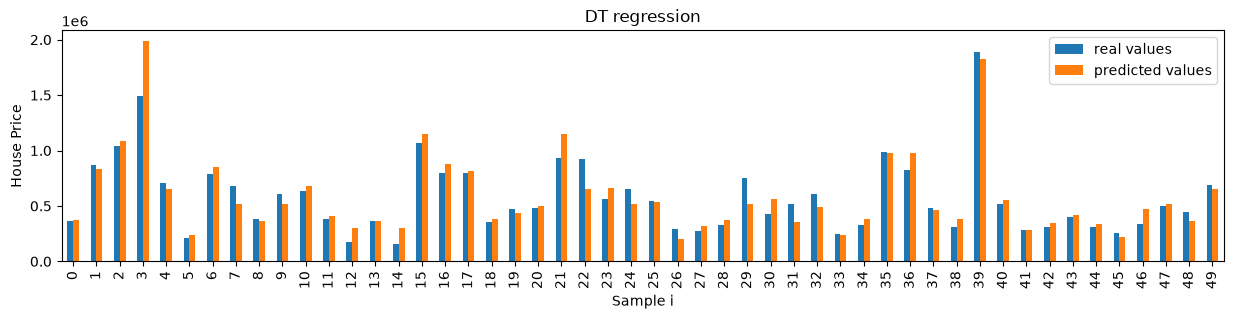

In [15]:
data1 = pd.Series(y_test[:50].ravel())
data2 = pd.Series(y_pred_dt[:50].ravel())

df_new = pd.concat([data1, data2], keys=['real values', 'predicted values'], axis=1)
df_new.plot(kind='bar', figsize=(15,3))

plt.title("DT regression")
plt.xlabel('Sample i')
plt.ylabel('House Price')
plt.show()

**c. Random Forest Regression**

In [16]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

print('coef of determination training ', rf.score(X_train, y_train))
print('coef of determination testing ', rf.score(X_test, y_test))

print('prediction')
y_pred_rf = rf.predict(X_test)
print(y_pred_rf[:10])
print('real value')
print(y_test[:10])

coef of determination training  0.9824630376725777
coef of determination testing  0.8539502679925459
prediction


[ 384004.    837783.05 1113406.9  2090339.5   714081.6   248461.53
  838403.88  628561.1   406003.45  568834.9 ]
real value
[ 365000.  865000. 1038000. 1490000.  711000.  211000.  790000.  680000.
  384500.  605000.]


*Evaluasi Model Random Forest dengan RMSE dan $R^2$*

In [17]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print('rmse : ', rmse_rf)
print('r2 : ', r2_rf)

rmse :  145205.69289959368
r2 :  0.8539502679925459


*Visualisasi Perbandingan Prediksi Random Forest (50 Sampel)*

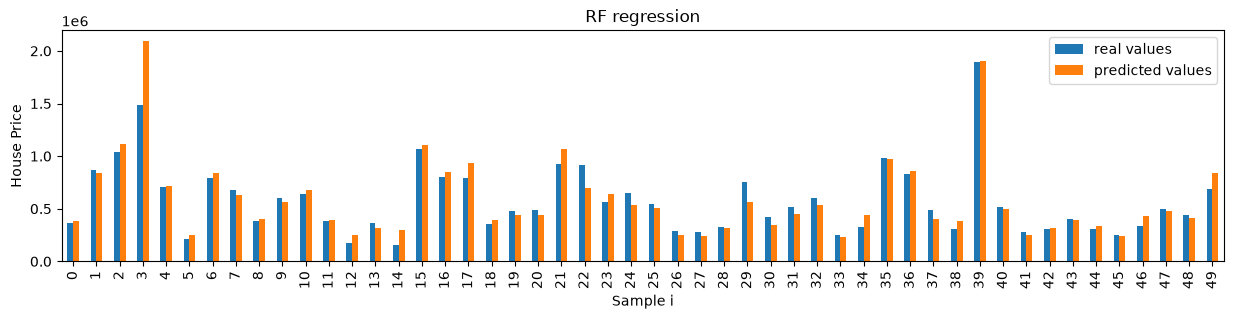

In [18]:
data1 = pd.Series(y_test[:50].ravel())
data2 = pd.Series(y_pred_rf[:50].ravel())

df_new = pd.concat([data1, data2], keys=['real values', 'predicted values'], axis=1)
df_new.plot(kind='bar', figsize=(15,3))

plt.title("RF regression")
plt.xlabel('Sample i')
plt.ylabel('House Price')
plt.show()

### Rekapitulasi Performa Model Percobaan (KC House Data)

In [19]:
df_kc_eval = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree Regression (max_depth=10)', 'Random Forest Regression'],
    'Train R2': [reg.score(X_train, y_train), dt.score(X_train, y_train), rf.score(X_train, y_train)],
    'Test R2': [r2, r2_dt, r2_rf],
    'RMSE': [rmse, rmse_dt, rmse_rf]
})
df_kc_eval

,Model,Train R2,Test R2,RMSE
0,Linear Regression,0.699516,0.699463,208296.727721
1,Decision Tree Regression (max_depth=10),0.918527,0.758616,186675.483970
2,Random Forest Regression,0.982463,0.853950,145205.692900


---
## B. TUGAS & ANALISIS (Car Price Prediction Dataset)
Dataset: [Car Price Prediction](https://www.kaggle.com/datasets/hellbuoy/car-price-prediction/data)

### 1. Tujuan Penggunaan Dataset & Definisi Input-Output
* **Tujuan Penggunaan Dataset**:
  Dataset ini digunakan untuk memprediksi estimasi harga jual mobil berdasarkan karakteristik teknis mesin, spesifikasi dimensi bodi, serta kategori kendaraan. Analisis ini membantu industri otomotif dalam memahami preferensi pasar dan menentukan strategi penetapan harga yang kompetitif.
* **Variabel Output (Target)**:
  * `price` (Numerik kontinu, satuan USD): Harga pasar dari kendaraan yang diprediksi.
* **Variabel Input (Fitur)**:
  * Fitur numerik: `symboling`, `wheelbase`, `carlength`, `carwidth`, `carheight`, `curbweight`, `enginesize`, `boreratio`, `stroke`, `compressionratio`, `horsepower`, `peakrpm`, `citympg`, `highwaympg`.
  * Fitur kategorikal: `fueltype`, `aspiration`, `doornumber`, `carbody`, `drivewheel`, `enginelocation`, `enginetype`, `cylindernumber`, `fuelsystem`.
  * Kolom identitas yang dieliminasi: `car_ID` (indeks/identitas unik) dan `CarName` (nama spesifik model mobil).

In [20]:
url_car = 'https://raw.githubusercontent.com/pranavhaldar/Car-Price_Linear-Regression-Assignment/master/CarPrice_Assignment.csv'
df_car = pd.read_csv(url_car)

print("Dimensi dataset:", df_car.shape)
df_car.head()

Dimensi dataset: (205, 26)


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


### 2. Variabel yang Paling Mempengaruhi Output (Korelasi Tinggi)

Koefisien Korelasi Fitur Numerik terhadap Price:
enginesize          0.874145
curbweight          0.835305
horsepower          0.808139
carwidth            0.759325
carlength           0.682920
wheelbase           0.577816
boreratio           0.553173
carheight           0.119336
stroke              0.079443
compressionratio    0.067984
symboling          -0.079978
peakrpm            -0.085267
citympg            -0.685751
highwaympg         -0.697599
Name: price, dtype: float64


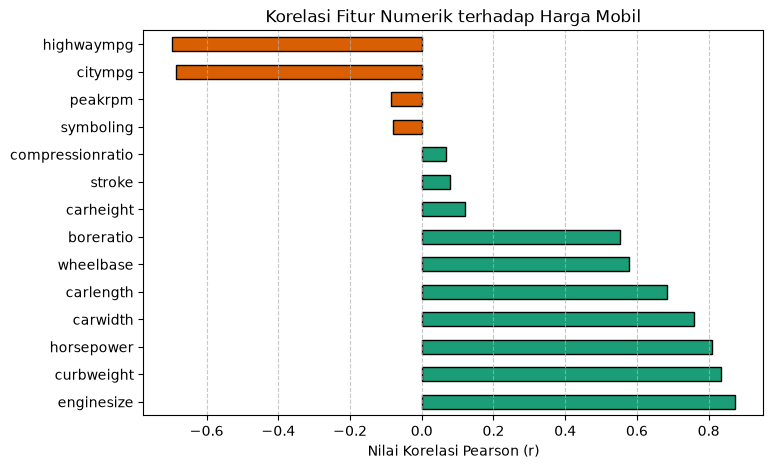

In [21]:
from scipy.stats import pearsonr

numeric_car = df_car.select_dtypes(include=[np.number]).drop('car_ID', axis=1)
corr_car = numeric_car.corr()['price'].drop('price').sort_values(ascending=False)

print("Koefisien Korelasi Fitur Numerik terhadap Price:")
print(corr_car)

# Visualisasi korelasi
plt.figure(figsize=(8, 5))
colors = ['#1b9e77' if c > 0 else '#d95f02' for c in corr_car.values]
corr_car.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Korelasi Fitur Numerik terhadap Harga Mobil')
plt.xlabel('Nilai Korelasi Pearson (r)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Analisis Variabel Berpengaruh:**
1. **`enginesize` ($r = 0.8741$)**: Kapasitas mesin memiliki korelasi positif paling dominan. Mobil dengan kapasitas silinder mesin besar selalu memiliki harga yang jauh lebih mahal.
2. **`curbweight` ($r = 0.8353$)**: Bobot kosong mobil memiliki korelasi sangat kuat. Mobil yang lebih berat umumnya memiliki struktur bodi lebih kokoh, fitur keselamatan lengkap, serta dimensi mewah.
3. **`horsepower` ($r = 0.8081$)**: Tenaga kuda mesin menjadi daya tarik performa utama pada segmen kendaraan premium.
4. **`carwidth` ($r = 0.7593$) dan `carlength` ($r = 0.6829$)**: Dimensi fisik mobil berkorelasi kuat terhadap kelas kenyamanan dan segmen mobil.
5. **`highwaympg` ($r = -0.6976$) dan `citympg` ($r = -0.6858$)**: Efisiensi bahan bakar berkorelasi negatif kuat, karena mobil mewah bertenaga besar umumnya memiliki konsumsi bahan bakar yang lebih boros.

### 3. Pembuatan Model Regresi (Linear, Decision Tree, Random Forest)

In [22]:
from sklearn.preprocessing import LabelEncoder

# Pra-pemrosesan Data
df_X_car = df_car.drop(['car_ID', 'CarName', 'price'], axis=1)
y_car = df_car['price'].values

le = LabelEncoder()
cats_car = df_X_car.select_dtypes(include=['object']).columns
for col in cats_car:
    df_X_car[col] = le.fit_transform(df_X_car[col].astype(str))

X_car = df_X_car.values.astype(float)

# Pembagian data latih dan uji (70:30)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_car, y_car, test_size=0.3, random_state=42)

# Inisialisasi Model
models_car = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regression': DecisionTreeRegressor(random_state=42),
    'Random Forest Regression': RandomForestRegressor(random_state=42)
}

preds_car = {}
results_car = []

for name, model in models_car.items():
    model.fit(X_train_c, y_train_c)
    y_pred = model.predict(X_test_c)
    preds_car[name] = y_pred
    
    rmse = np.sqrt(mean_squared_error(y_test_c, y_pred))
    r2 = r2_score(y_test_c, y_pred)
    r = pearsonr(y_test_c, y_pred)[0]
    
    results_car.append({
        'model': name,
        'RMSE': rmse,
        'R2': r2,
        'R': r
    })

print("Pelatihan ketiga model selesai!")

Pelatihan ketiga model selesai!


/var/folders/xf/zj61nc_j3hlcbvxzsf8hfp0h0000gn/T/ipykernel_14272/1710498610.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cats_car = df_X_car.select_dtypes(include=['object']).columns


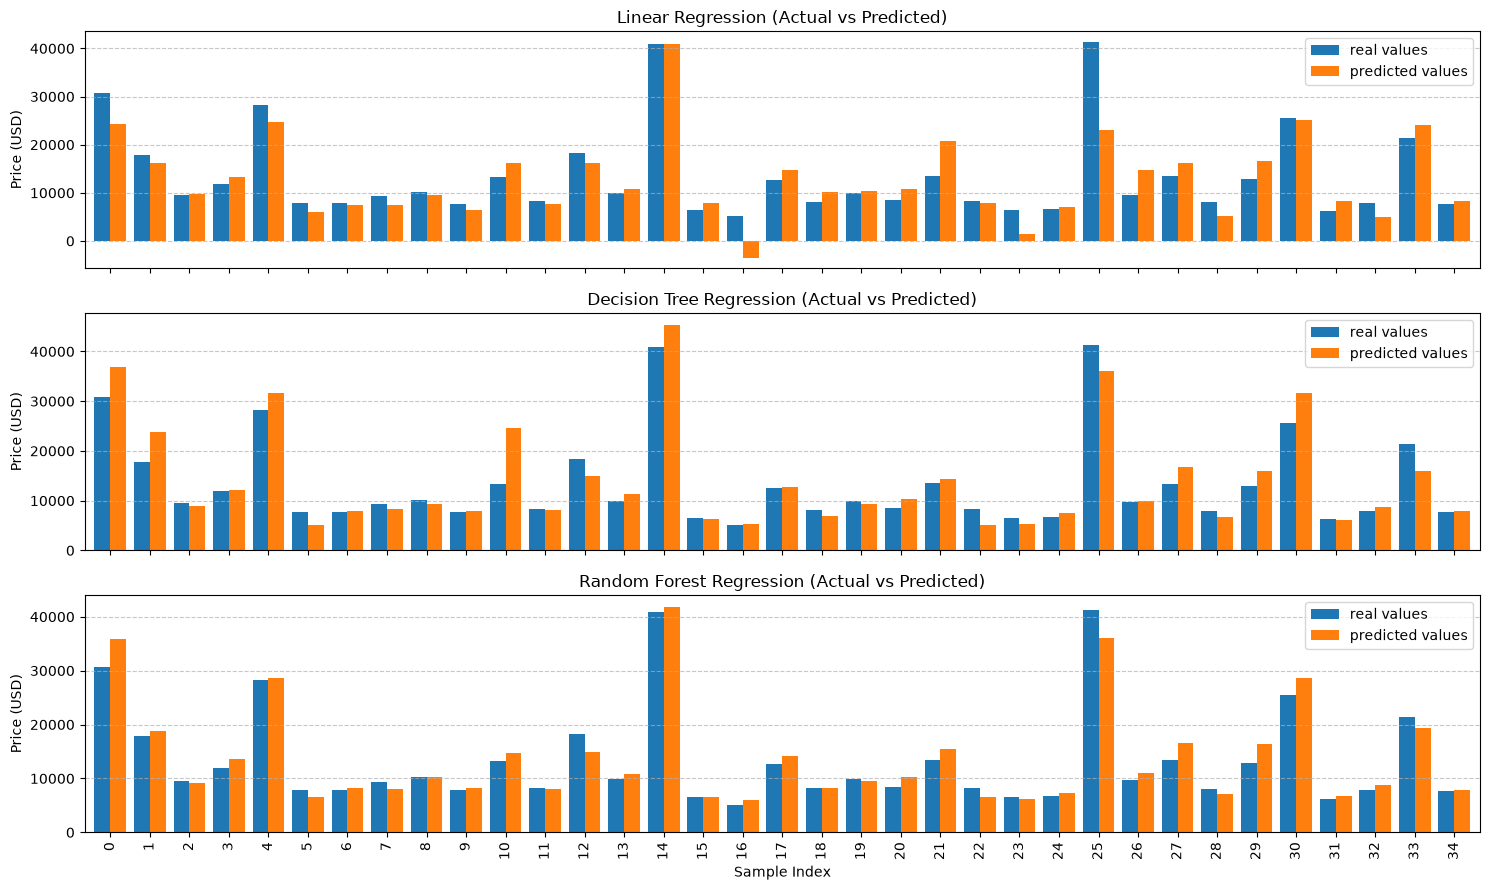

In [23]:
# Visualisasi perbandingan prediksi pada 35 sampel data uji
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
sample_n = 35

for idx, (name, pred) in enumerate(preds_car.items()):
    df_plot = pd.DataFrame({
        'real values': y_test_c[:sample_n],
        'predicted values': pred[:sample_n]
    })
    df_plot.plot(kind='bar', ax=axes[idx], color=['#1f77b4', '#ff7f0e'], width=0.8)
    axes[idx].set_title(f"{name} (Actual vs Predicted)")
    axes[idx].set_ylabel("Price (USD)")
    axes[idx].grid(axis='y', linestyle='--', alpha=0.7)

plt.xlabel("Sample Index")
plt.tight_layout()
plt.show()

### 4. Tabel Performa Model Machine Learning (Car Price)

In [24]:
df_results_car = pd.DataFrame(results_car)
df_results_car

,model,RMSE,R2,R
0,Linear Regression,3722.327686,0.800017,0.896760
1,Decision Tree Regression,2994.766196,0.870553,0.944888
2,Random Forest Regression,1955.867327,0.944787,0.972704


### 5. Analisis Pemilihan Model Terbaik

Berdasarkan hasil evaluasi pada tabel performa di atas:
* **Random Forest Regression** merupakan model yang paling baik.

**Alasan Pemilihan**:
1. **Nilai RMSE Paling Rendah ($1955.87$)**: Rata-rata margin kesalahan estimasi harga Random Forest jauh lebih kecil dibandingkan Decision Tree ($2994.77$) maupun Linear Regression ($3722.33$).
2. **Nilai $R^2$ Tertinggi ($0.9448$)**: Model Random Forest mampu menjelaskan 94.48% variasi harga mobil, sedangkan Linear Regression hanya mampu menjelaskan 80.00%.
3. **Korelasi Prediksi ($R$) Paling Kuat ($0.9727$)**: Nilai korelasi Pearson mendekati sempurna, menunjukkan prediksi model selaras rapat dengan harga sebenarnya.
4. **Generalisasi Lebih Stabil**: Pendekatan ansambel pada Random Forest menggabungkan puluhan pohon keputusan dengan teknik bagging, sehingga memangkas varians data dan mencegah bias overfitting yang sering menjebak Decision Tree tunggal.